In [1]:
import scanpy as sc
import anndata as ad

In [2]:
%%time
adata = sc.read_h5ad('../../certpro-data/final-objects/final-bmmc-raw.h5ad')

CPU times: user 14.2 s, sys: 54.9 s, total: 1min 9s
Wall time: 3min 13s


In [3]:
%%time
sc.pp.calculate_qc_metrics(adata)

CPU times: user 1min 35s, sys: 10.4 s, total: 1min 45s
Wall time: 1min


(                                  n_genes_by_counts  log1p_n_genes_by_counts  \
 barcodes                                                                       
 97396d7e733f11ee811062d5ef28e4ea               2295                 7.738924   
 97397620733f11ee811062d5ef28e4ea               2947                 7.988882   
 97397850733f11ee811062d5ef28e4ea               4623                 8.439015   
 97397972733f11ee811062d5ef28e4ea               1791                 7.491088   
 9739820a733f11ee811062d5ef28e4ea               3112                 8.043342   
 ...                                             ...                      ...   
 50907fa27db111efbb201a1ce35e11c5               3205                 8.072779   
 50909fe67db111efbb201a1ce35e11c5               2034                 7.618251   
 5090b5947db111efbb201a1ce35e11c5               3265                 8.091321   
 5090b95e7db111efbb201a1ce35e11c5               1579                 7.365180   
 5090d3c67db111efbb201a1ce35

In [4]:
%%time
sc.pp.normalize_total(adata)

CPU times: user 18.4 s, sys: 10 s, total: 28.4 s
Wall time: 28.5 s


In [5]:
%%time
sc.pp.log1p(adata)

CPU times: user 31.5 s, sys: 0 ns, total: 31.5 s
Wall time: 31.5 s


In [6]:
%%time
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.25)

CPU times: user 1min 14s, sys: 7.49 s, total: 1min 22s
Wall time: 47.8 s


In [7]:
%%time
sc.pp.scale(adata, max_value=10, zero_center=False)

CPU times: user 57 s, sys: 3.28 s, total: 1min
Wall time: 13.7 s


In [8]:
%%time
sc.pp.pca(adata, svd_solver="arpack")

CPU times: user 10min 35s, sys: 10min 32s, total: 21min 8s
Wall time: 3min 13s


In [9]:
%%time
sc.pp.neighbors(adata, n_neighbors=50, use_rep="X_pca", n_pcs=20)

CPU times: user 11min 5s, sys: 20.3 s, total: 11min 25s
Wall time: 11min 51s


In [10]:
%%time
sc.tl.umap(adata, min_dist=0.45, init_pos = 'random', random_state=0, n_components=2)

CPU times: user 21min 45s, sys: 4.98 s, total: 21min 50s
Wall time: 21min 43s


In [11]:
%%time
sc.tl.leiden(adata, resolution=1, n_iterations=2)

<timed eval>:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.


CPU times: user 8min 4s, sys: 18.6 s, total: 8min 23s
Wall time: 8min 23s


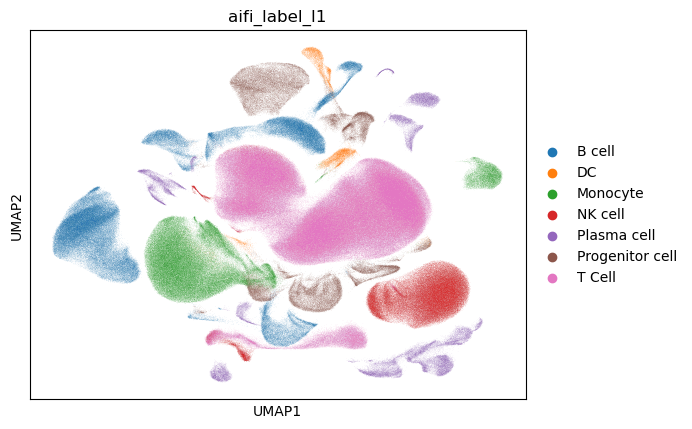

In [12]:
sc.pl.umap(adata, color = 'aifi_label_l1')

In [13]:
adata.write('save_normal_results.h5ad')

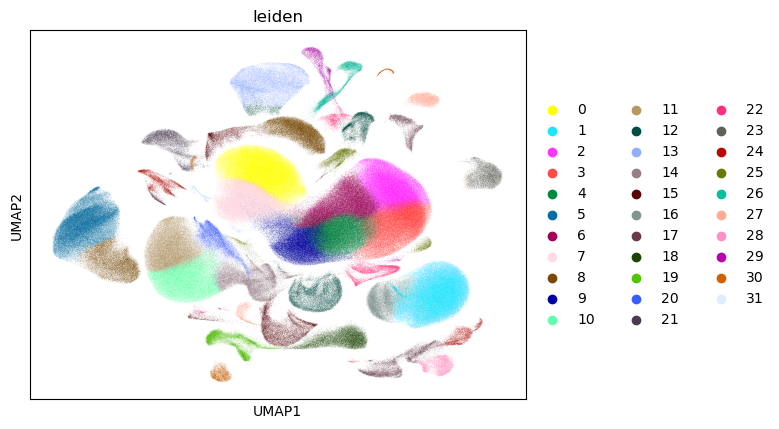

In [14]:
sc.pl.umap(adata, color = 'leiden')